In [1]:
# 1. Load Dataset
data(mtcars)
cars_data <- mtcars

In [2]:
# 2. Descriptive Statistics

cat("Minimum MPG:", min(cars_data$mpg), "\n")
cat("Maximum MPG:", max(cars_data$mpg), "\n")
cat("Mean MPG:", mean(cars_data$mpg), "\n")
cat("Variance MPG:", var(cars_data$mpg), "\n")
cat("Standard Deviation MPG:", sd(cars_data$mpg), "\n")
cat("Percentiles:\n")
print(quantile(cars_data$mpg))

Minimum MPG: 10.4 
Maximum MPG: 33.9 
Mean MPG: 20.09062 
Variance MPG: 36.3241 
Standard Deviation MPG: 6.026948 
Percentiles:
    0%    25%    50%    75%   100% 
10.400 15.425 19.200 22.800 33.900 


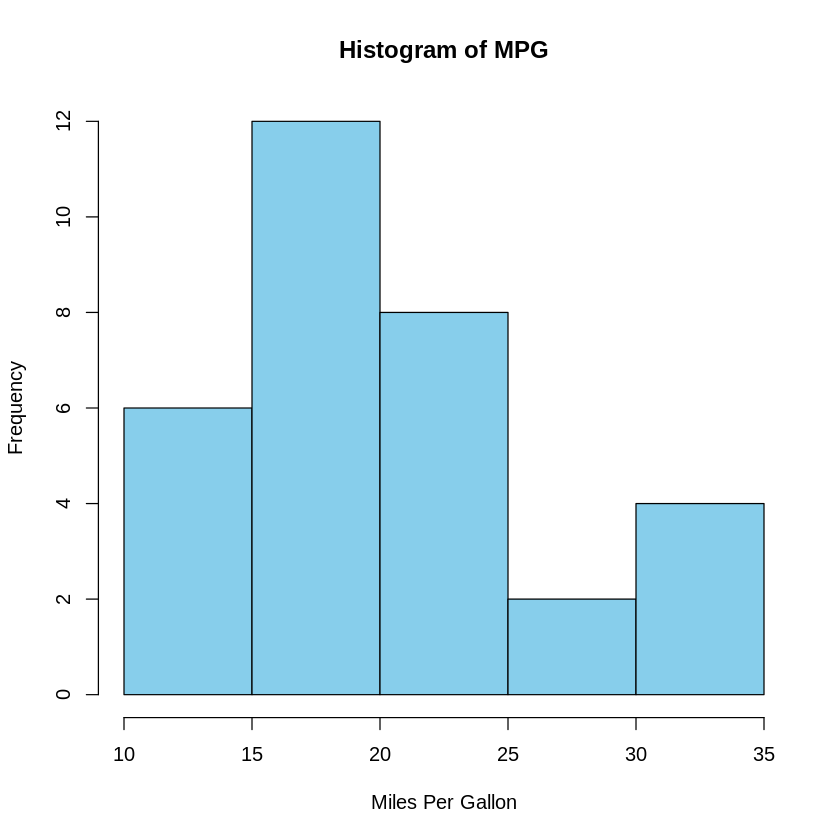

In [3]:
# 3. Data Visualization

# Histogram
hist(cars_data$mpg,
     main="Histogram of MPG",
     col="skyblue",
     xlab="Miles Per Gallon")


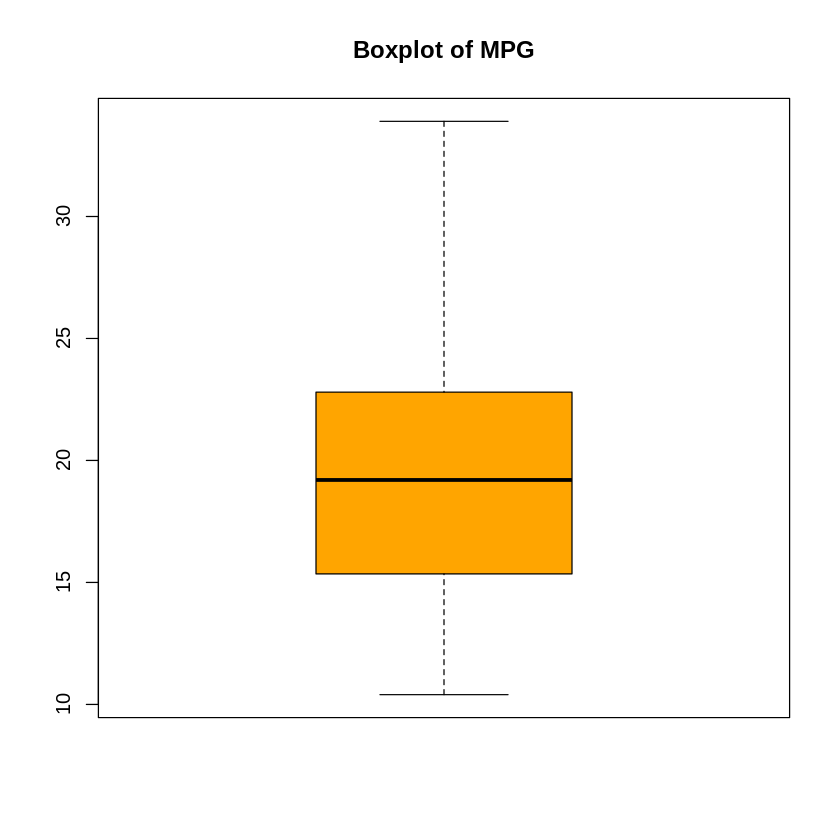

In [4]:
# Boxplot
boxplot(cars_data$mpg,
        main="Boxplot of MPG",
        col="orange")

In [5]:
# 4. Z-Test (Manual Calculation)
# H0: Mean MPG = 20

xbar <- mean(cars_data$mpg)
mu <- 20
sigma <- sd(cars_data$mpg)
n <- length(cars_data$mpg)

z_value <- (xbar - mu) / (sigma / sqrt(n))

cat("Z-Test Value:", z_value, "\n")

Z-Test Value: 0.08506004 


In [6]:
# 5. One Sample T-Test

t_test_result <- t.test(cars_data$mpg, mu=20)
print(t_test_result)


	One Sample t-test

data:  cars_data$mpg
t = 0.08506, df = 31, p-value = 0.9328
alternative hypothesis: true mean is not equal to 20
95 percent confidence interval:
 17.91768 22.26357
sample estimates:
mean of x 
 20.09062 



In [8]:
# 6. ANOVA Test
# Compare MPG based on cylinder

anova_result <- aov(mpg ~ factor(cyl), data=cars_data)
summary(anova_result)


            Df Sum Sq Mean Sq F value   Pr(>F)    
factor(cyl)  2  824.8   412.4    39.7 4.98e-09 ***
Residuals   29  301.3    10.4                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [10]:
# 7. A/B Testing (Independent T-Test)
# Compare 4-cylinder and 6-cylinder cars

groupA <- subset(cars_data, cyl==4)$mpg
groupB <- subset(cars_data, cyl==6)$mpg

ab_test <- t.test(groupA, groupB)
print(ab_test)


	Welch Two Sample t-test

data:  groupA and groupB
t = 4.7191, df = 12.956, p-value = 0.0004048
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
  3.751376 10.090182
sample estimates:
mean of x mean of y 
 26.66364  19.74286 



In [11]:
# ---------------------------------------------------
# Z-TEST USING DATASET (Two-tailed test)
# ---------------------------------------------------

# Step 1: Dataset (n = 36)
data <- c(
  168, 170, 169, 171, 167, 172, 170, 168, 169,
  171, 170, 169, 168, 172, 171, 170, 169, 168,
  171, 170, 169, 172, 168, 170, 171, 169, 168,
  170, 171, 169, 172, 168, 170, 169, 171
)

# Step 2: Given values
mu0 <- 168        # Population mean
sigma <- 3.9      # Population standard deviation
alpha <- 0.05     # Significance level

# Step 3: Sample statistics
n <- length(data)
xbar <- mean(data)

# Step 4: Hypotheses
cat("Null Hypothesis H0: mu = 168\n")
cat("Alternative Hypothesis H1: mu != 168\n\n")

# Step 5: Z-test statistic
z_value <- (xbar - mu0) / (sigma / sqrt(n))

# Step 6: Critical value (two-tailed)
z_critical <- qnorm(1 - alpha/2)

# Step 7: P-value
p_value <- 2 * (1 - pnorm(abs(z_value)))

# Step 8: Results
cat("Sample Size (n):", n, "\n")
cat("Sample Mean (x̄):", xbar, "\n")
cat("Z-Calculated:", z_value, "\n")
cat("Z-Critical:", z_critical, "\n")
cat("P-Value:", p_value, "\n\n")

# Step 9: Decision
if (abs(z_value) > z_critical) {
  cat("Decision: Reject the Null Hypothesis\n")
  cat("Conclusion: Mean height is significantly different from 168 cm\n")
} else {
  cat("Decision: Fail to Reject the Null Hypothesis\n")
  cat("Conclusion: No significant difference in mean height\n")
}


Null Hypothesis H0: mu = 168
Alternative Hypothesis H1: mu != 168

Sample Size (n): 35 
Sample Mean (x̄): 169.7143 
Z-Calculated: 2.600475 
Z-Critical: 1.959964 
P-Value: 0.00930949 

Decision: Reject the Null Hypothesis
Conclusion: Mean height is significantly different from 168 cm
